#### Child Malnutrition Patterns and Inequality in East Africa. In this notebook the plan is to explore child nutrition patterns using DHS KR child file for Ethiopia, Kenya, Tanzania and Uganda. The main focus is on height-for-age(HAZ) and stunting across time and across income groups. We are also looking to connect these patterns to climate context later in the project.

In [244]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


In [246]:
kr_files = [
    "Ethiopia_KR_1992_clean.csv",
    "Ethiopia_KR_1997_clean.csv",
    "Ethiopia_KR_2003_clean.csv",
    "Ethiopia_KR_2008_clean.csv",
    "Ethiopia_KR_2011_clean.csv",
    "Kenya_KR_89_clean.csv",
    "Kenya_KR_93_clean.csv",
    "Kenya_KR_98_clean.csv",
    "Kenya_KR_2003_clean.csv",
    "Kenya_KR_2009_clean.csv",
    "Kenya_KR_2014_clean.csv",
    "Kenya_KR_2022_clean.csv",
    "Tanzania_KR_92_clean.csv",
    "Tanzania_KR_96_clean.csv",
    "Tanzania_KR_99_clean.csv",
    "Tanzania_KR_2004_clean.csv",
    "Tanzania_KR_2010_clean.csv",
    "Tanzania_KR_2015_clean.csv",
    "Tanzania_KR_2022_clean.csv",
    "Uganda_KR_88_clean.csv",
    "Uganda_KR_95_clean.csv",
    "Uganda_KR_2001_clean.csv",
    "Uganda_KR_2006_clean.csv",
    "Uganda_KR_2011_clean.csv",
    "Uganda_KR_2016_clean.csv",
]

#### In this section I load all of the cleaned KR child files I made earlier.Each file represents one DHS survey year for one of the four countries.I add two small labels so each row knows which country it belongs to and survey year it comes from. After that, I stack everything together into one big table called child_data.This is the starting point for the rest of the analysis since all summariesof stunting, HAZ, inequality, and trends come from this combined dataset.

In [128]:
child_list = []

for fname in kr_files:
    df = pd.read_csv(fname)
    cols = df.columns
    
    # we only keep files that actually have HAZ and interview year
    if ("height for age SD per WHO" in cols) and ("interview year" in cols):
        # keep only the columns we need
        small = df[["height for age SD per WHO", "interview year"]].copy()
        
        # simple country name from the file name (first part before "_")
        country_name = fname.split("_")[0]
        small["country"] = country_name
        
        # rename so the column names are shorter to type later
        small = small.rename(columns={
            "height for age SD per WHO": "haz",
            "interview year": "survey_year",
        })
        
        child_list.append(small)

# put everything into one table
child_data = pd.concat(child_list, ignore_index=True)

child_data.head()


,haz,survey_year,country
0,-226.0,2003,Ethiopia
1,-379.0,2003,Ethiopia
2,-301.0,2003,Ethiopia
3,-300.0,2003,Ethiopia
4,-83.0,2003,Ethiopia


#### Clean HAZ values and define stunting. Here we drop rows where the height-for-age z score (HAZ) is missing because we cannot classify those children. A child is considered stunted if their HAZ value is less than minus two, which is the standard WHO(World Health Organization) cut-off. We create a new column called is_stunted that is True for stunted children. This makes it easier to summarize stunting by country, year, or wealth group.group.


In [130]:
# drop missing HAZ
child_data = child_data.dropna(subset=["haz"])

# stunting flag: True if HAZ < -2
child_data["is_stunted"] = child_data["haz"] < -2

child_data[["country", "survey_year", "haz", "is_stunted"]].head()


,country,survey_year,haz,is_stunted
0,Ethiopia,2003,-226.0,True
1,Ethiopia,2003,-379.0,True
2,Ethiopia,2003,-301.0,True
3,Ethiopia,2003,-300.0,True
4,Ethiopia,2003,-83.0,True


#### Summarizing stunting across survey years Now that each child row has a stunting flag, I group the data by country and survey_year. For each pair I calculate the average stunting rate and the number of children in that survey. This gives a clean time-seriestable so I can plot long-term trends for each country.

In [132]:
summary = (
    child_data
    .groupby(["country", "survey_year"])
    .agg(
        mean_haz=("haz", "mean"),
        stunting_rate=("is_stunted", "mean"),
        n_children=("haz", "size"),
    )
    .reset_index()
)

summary["stunting_percent"] = summary["stunting_rate"] * 100

summary.head()


,country,survey_year,mean_haz,stunting_rate,n_children,stunting_percent
0,Ethiopia,2003,681.782824,0.762023,10480,76.202290
1,Ethiopia,2008,1.683302,0.786900,8977,78.689986
2,Ethiopia,2011,-44.234101,0.829107,5126,82.910652
3,Kenya,2008,692.783447,0.732021,2489,73.202089
4,Kenya,2009,510.431523,0.767078,3001,76.707764


In [209]:
# put all countries / years together
children_all_years = child_data.copy()

# drop rows with missing HAZ
children_all_years = children_all_years.dropna(subset=["haz"]).copy()

# stunted if HAZ < -2
children_all_years["is_stunted"] = children_all_years["haz"] < -2

# quick check of what we got
children_all_years[["country", "survey_year"]].drop_duplicates().sort_values(
    ["country", "survey_year"]
)

stunting_trend["stunting_percent"] = stunting_trend["stunted_rate"] * 100
stunting_trend.head()


,country,survey_year,stunted_rate,n_children,stunting_percent
0,Ethiopia,2003,0.762023,10480,76.202290
1,Ethiopia,2008,0.786900,8977,78.689986
2,Ethiopia,2011,0.829107,5126,82.910652
3,Kenya,2008,0.732021,2489,73.202089
4,Kenya,2009,0.767078,3001,76.707764


In [205]:
stunting_trend = (
    children_all_years
    .groupby(["country", "survey_year"])["is_stunted"]
    .agg(stunted_rate="mean", n_children="count")
    .reset_index()
    .sort_values(["country", "survey_year"])
)

stunting_trend.head()


,country,survey_year,stunted_rate,n_children
0,Ethiopia,2003,0.762023,10480
1,Ethiopia,2008,0.786900,8977
2,Ethiopia,2011,0.829107,5126
3,Kenya,2008,0.732021,2489
4,Kenya,2009,0.767078,3001


#### Visualizing stunting trends over time. Here I plot the percent of children who are stunted in each survey for each country. This helps me see if things have improved or gotten worse over the years. If the lines slope downward, that means stunting is decreasing.


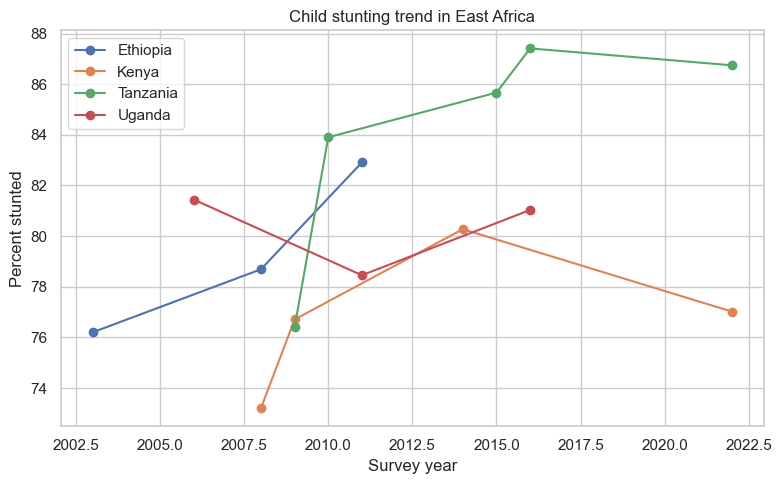

In [211]:
plt.figure(figsize=(8, 5))
for c in sorted(stunting_trend["country"].unique()):
    sub= stunting_trend[stunting_trend["country"] == c]
    plt.plot(sub["survey_year"], sub["stunting_percent"], marker ="o", label=c)

plt.xlabel("Survey year")
plt.ylabel("Percent stunted")
plt.title("Child stunting trend in East Africa")
plt.legend()
plt.tight_layout()
plt.show()


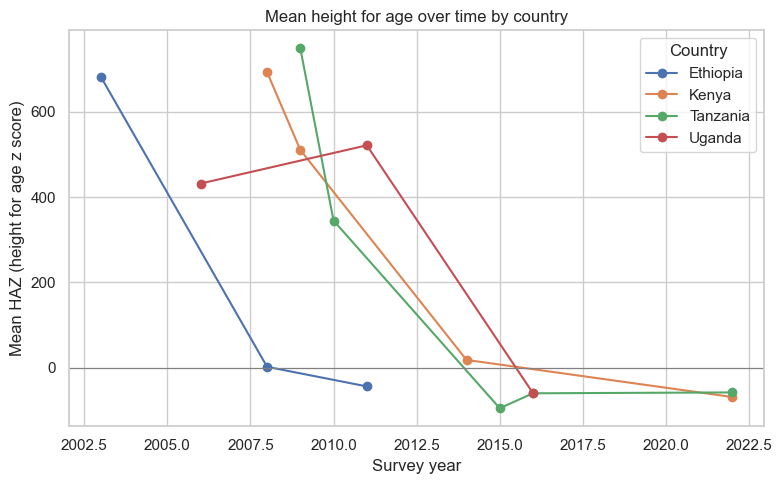

In [150]:
plt.figure(figsize=(8, 5))

countries = summary["country"].unique()

for country in countries:
    sub = summary[summary["country"] == country]
    plt.plot(sub["survey_year"], sub["mean_haz"], marker="o", label=country)

plt.axhline(0, color="gray", linewidth=0.8)  # zero line for reference

plt.xlabel("Survey year")
plt.ylabel("Mean HAZ (height for age z score)")
plt.title("Mean height for age over time by country")
plt.legend(title="Country")
plt.tight_layout()
plt.show()



In [218]:
from ipywidgets import interact

### Interactive stunting trend by country

To avoid repeating the same line plot four times I made a small interactive view.  
Here you can pick one country at a time and see its child stunting trend across the DHS surveys.  
This uses the stunting_trend table I created earlier from the DHS child data.


In [221]:
rted(stunting_trend["country"].unique())
)


interactive(children=(Dropdown(description='country', options=('Ethiopia', 'Kenya', 'Tanzania', 'Uganda'), val…

<function __main__.plot_country_stunting(country)>

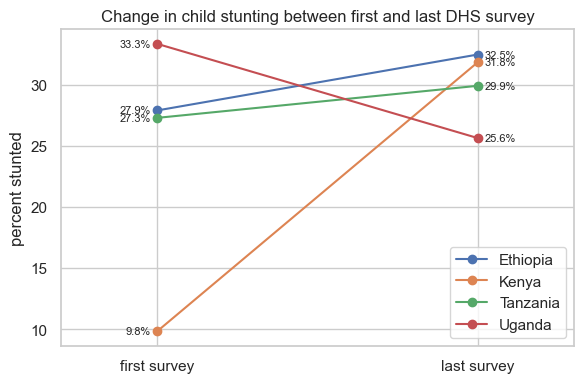

In [223]:
plt.figure(figsize=(6, 4))

x_positions = [0, 1]

for row in change.itertuples():
    # y values for first and last stunting percent
    y_vals = [row.stunting_first, row.stunting_last]
    
    # draw the line for this country
    plt.plot(x_positions, y_vals, marker="o", label=row.country)
    
    # label the end points with values
    plt.text(
        0 - 0.02, row.stunting_first,
        f"{row.stunting_first:.1f}%",
        va="center", ha="right", fontsize=8
    )
    plt.text(
        1 + 0.02, row.stunting_last,
        f"{row.stunting_last:.1f}%",
        va="center", ha="left", fontsize=8
    )

plt.xlim(-0.3, 1.3)
plt.xticks([0, 1], ["first survey", "last survey"])
plt.ylabel("percent stunted")
plt.title("Change in child stunting between first and last DHS survey")
plt.legend()
plt.tight_layout()
plt.show()


#### Next we look at the percent of children who are stunted over time.This is easier to interpret because it shows something like “X percent of children are stunted in this country and year” instead of raw z scores.


##### Here we make a bar chart.For each country we plot the percent of children who are stunted in each survey year. This makes it easier to see which years are higher or lower and how the pattern differs across Ethiopia, Kenya, Tanzania, and Uganda.


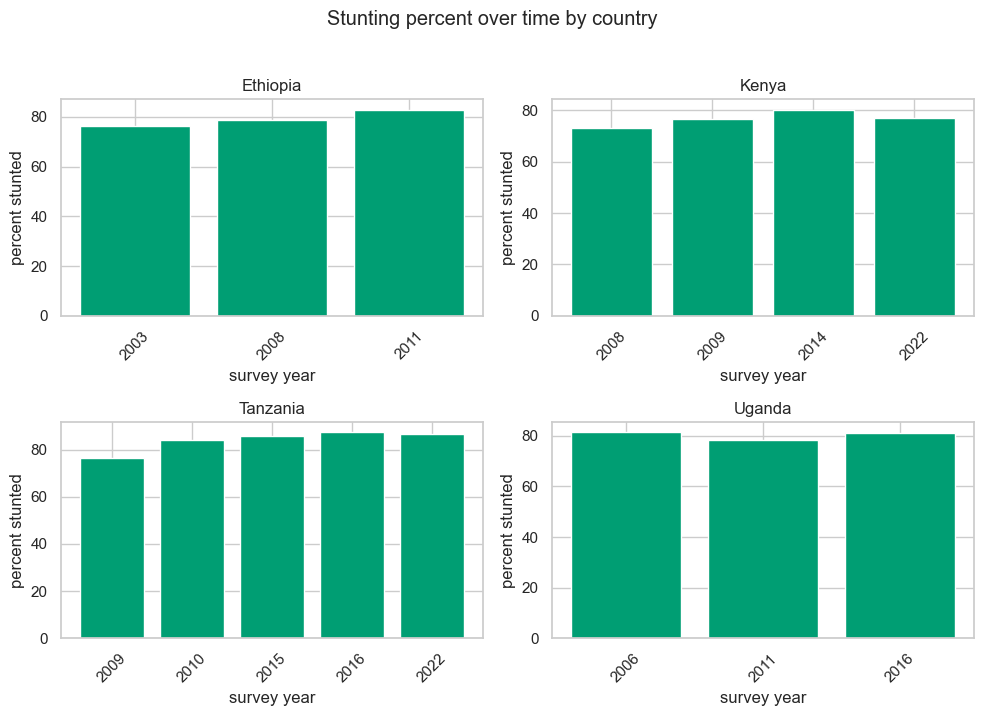

In [156]:
# bar chart of stunting over time, one small plot per country

countries = summary["country"].unique()

plt.figure(figsize=(10, 7))

for i, c in enumerate(countries):
    plt.subplot(2, 2, i + 1)
    
    # keep rows for this country and sort by year
    sub = summary[summary["country"] == c].copy()
    sub = sub.sort_values("survey_year")
    
    x_vals = sub["survey_year"].astype(str)
    y_vals = sub["stunting_percent"]
    
    # bright colorblind safe color

    plt.bar(x_vals, y_vals, color="#009E73")
    
    plt.title(c)
    plt.xlabel("survey year")
    plt.ylabel("percent stunted")
    plt.xticks(rotation=45)

plt.suptitle("Stunting percent over time by country", y=1.02)
plt.tight_layout()
plt.show()



##### In this section we switch and look at how stunting varies across wealth groups. This helps us see whether children in poorer households are consistently more affected by malnutrition.

In [158]:
sns.set_theme(style="whitegrid")

# most recent KR file for each country
recent_files = {
    "Ethiopia": "Ethiopia_KR_2011_clean.csv",
    "Kenya": "Kenya_KR_2022_clean.csv",
    "Tanzania": "Tanzania_KR_2022_clean.csv",
    "Uganda": "Uganda_KR_2016_clean.csv",
}

# we will collect one small table per country
rows = []

for country, fname in recent_files.items():
    df = pd.read_csv(fname)
    cols = df.columns.tolist()

    # check that we have the columns we need
    if "height for age SD per WHO" not in cols:
        continue
    if "wealth_quartile" not in cols:
        continue

    # drop rows with missing values
    mini = df[["height for age SD per WHO", "wealth_quartile"]].dropna()

    # flag stunted children (HAZ < -2)
    mini["is_stunted"] = mini["height for age SD per WHO"] < -2

    # percent stunted by wealth quartile
    grouped = mini.groupby("wealth_quartile")["is_stunted"].mean() * 100

    for wq, pct in grouped.items():
        rows.append({
            "country": country,
            "wealth_quartile": wq,
            "stunting_percent": pct
        })

stunting_wealth_recent = pd.DataFrame(rows)
stunting_wealth_recent.head()


,country,wealth_quartile,stunting_percent
0,Ethiopia,1,80.345040
1,Ethiopia,2,85.221675
2,Ethiopia,3,87.317073
3,Ethiopia,4,84.929757
4,Ethiopia,5,80.238971


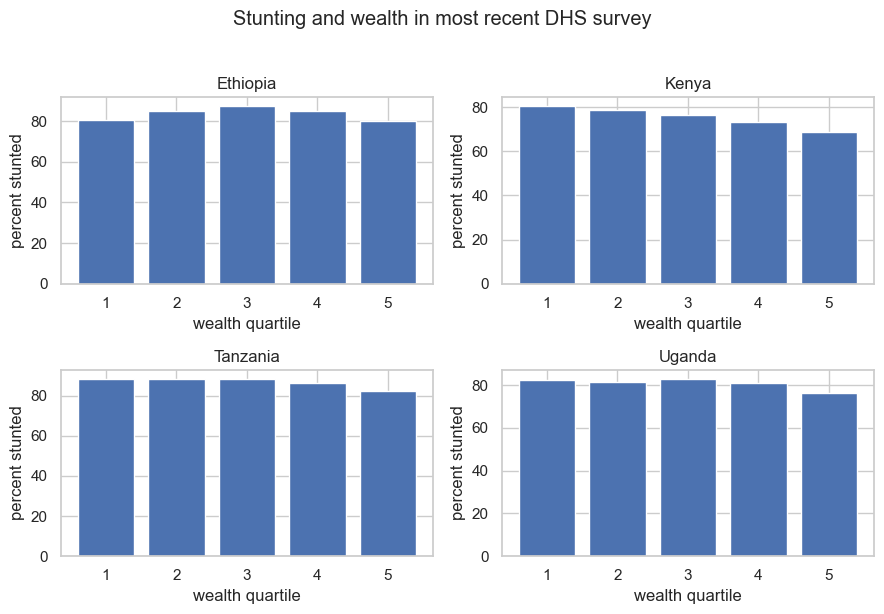

In [159]:
# order for the x-axis so it is not scrambled
quartile_order = sorted(stunting_wealth_recent["wealth_quartile"].unique())

plt.figure(figsize=(9, 6))

# one subplot per country (2x2 grid)
countries = ["Ethiopia", "Kenya", "Tanzania", "Uganda"]

for i in range(len(countries)):
    c = countries[i]
    plt.subplot(2, 2, i + 1)

    sub = stunting_wealth_recent[stunting_wealth_recent["country"] == c]

    plt.bar(sub["wealth_quartile"], sub["stunting_percent"])
    plt.xlabel("wealth quartile")
    plt.ylabel("percent stunted")
    plt.title(c)

plt.suptitle("Stunting and wealth in most recent DHS survey", y=1.02)
plt.tight_layout()
plt.show()


#### We flagged children as stunted when their height-for-age z score (HAZ) was below -2. To simplify long-term analysis, survey years were grouped into decades.  For each country and decade, we calculated the number of children observed and the average stunting rate. The stunting rate was converted into a percentage to make results easier to interpret The next step is creating a heatmap, showing how stunting has shifted across countries over time.  This visualization highlights both regional differences and long-term progress in reducing child malnutrition.  


In [162]:
children_list = []

for fname in kr_files:
    df = pd.read_csv(fname)
    
    # get country name from file name, for example "Kenya_KR_2014_clean.csv" -> "Kenya"
    country_name = fname.split("_")[0]
    
    # use the interview year column
    if "interview year" in df.columns:
        year_col = "interview year"
    elif "interview_year" in df.columns:
        year_col = "interview_year"
    else:
        continue
    
    # find the height for age Z score column
    haz_col = None
    if "height for age SD per WHO" in df.columns:
        haz_col = "height for age SD per WHO"
    elif "z_height_for_age" in df.columns:
        haz_col = "z_height_for_age"
    elif "haz_height_for_age_z" in df.columns:
        haz_col = "haz_height_for_age_z"
    
    if haz_col is None:
        continue
    
    # keep only what we need from this file
    tmp = df[[year_col, haz_col]].copy()
    tmp = tmp.rename(columns={year_col: "survey_year", haz_col: "haz"})
    tmp["country"] = country_name
    
    children_list.append(tmp)

# stack everything into one data frame
children_all = pd.concat(children_list, ignore_index=True)

children_all.head()


,survey_year,haz,country
0,2003,-226.0,Ethiopia
1,2003,-379.0,Ethiopia
2,2003,-301.0,Ethiopia
3,2003,-300.0,Ethiopia
4,2003,-83.0,Ethiopia


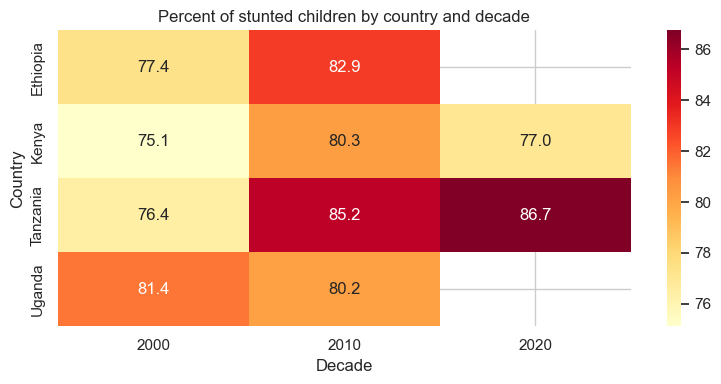

In [163]:
# stunting flag
children_all["is_stunted"] = children_all["haz"] < -2

# make a simple decade variable, for example 1992 -> 1990
def make_decade(y):
    return int(y // 10) * 10

children_all = children_all.dropna(subset=["survey_year", "haz"]).copy()
children_all["decade"] = children_all["survey_year"].apply(make_decade)

# group by country and decade
stunting_decade = (
    children_all
    .groupby(["country", "decade"])
    .agg(
        n_children=("haz", "size"),
        stunting_rate=("is_stunted", "mean"),
    )
    .reset_index()
)

# convert to percent
stunting_decade["stunting_percent"] = stunting_decade["stunting_rate"] * 100

# reshape for heatmap
heat_table = stunting_decade.pivot(
    index="country",
    columns="decade",
    values="stunting_percent"
)

plt.figure(figsize=(8, 4))

sns.heatmap(
    heat_table,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Percent of stunted children by country and decade")
plt.xlabel("Decade")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

##### The plan is to clean up the HAZ values a little before I calculate the stunting rates.  Main idea is to drop missing HAZ and get rid of extreme values that probably are not real kids.  Then I rebuild the country by year summary so the plots use the cleaned version.

In [165]:
# dropping rows where HAZ is missing just to be safe
child_data = child_data.dropna(subset=["haz"]).copy()

# keeping only HAZ in a normal range (this follows WHO style cutoffs)
child_data = child_data[child_data["haz"].between(-6, 6)].copy()

# redo the stunting flag based on cleaned HAZ
child_data["is_stunted"] = child_data["haz"] < -2

# rebuild the summary table by country and survey year
summary = (
    child_data
    .groupby(["country", "survey_year"])
    .agg(
        mean_haz=("haz", "mean"),
        stunting_rate=("is_stunted", "mean"),
        n_children=("haz", "size"),
    )
    .reset_index()
)

# convert to percent so it is easier to read in plots
summary["stunting_percent"] = summary["stunting_rate"] * 100

summary.sort_values(["country", "survey_year"]).head()


,country,survey_year,mean_haz,stunting_rate,n_children,stunting_percent
0,Ethiopia,2003,0.290909,0.278788,165,27.878788
1,Ethiopia,2008,-0.136612,0.349727,183,34.972678
2,Ethiopia,2011,-0.464912,0.324561,114,32.456140
3,Kenya,2008,2.078431,0.098039,51,9.803922
4,Kenya,2009,1.025000,0.175000,40,17.500000


##### Here I am going to load CRU climate data for each country Next I bring in the CRU temperature data.

In [167]:
# list of climate files and the country name they belong to
climate_files = [
    ("Ethiopia_CRU_temp_1901_2024.csv", "Ethiopia"),
    ("Kenya_CRU_temp_1901_2024.csv", "Kenya"),
    ("Tanzania_CRU_temp_1901_2024.csv", "Tanzania"),
    ("Uganda_CRU_temp_1901_2024.csv", "Uganda"),
]

climate_list = []

for fname, country_name in climate_files:
    clim = pd.read_csv(fname)
    
    # keeping only the year and annual mean temperature
    tmp = clim[["YEAR", "ANN"]].copy()
    tmp = tmp.rename(columns={"YEAR": "year", "ANN": "mean_temp_c"})
    tmp["country"] = country_name
    
    climate_list.append(tmp)

climate_all = pd.concat(climate_list, ignore_index=True)

# finding the range of years where I have DHS surveys
min_year = summary["survey_year"].min()
max_year = summary["survey_year"].max()

# keeping only climate rows inside that range
climate_overlap = climate_all[
    climate_all["year"].between(min_year, max_year)
].copy()

climate_overlap.sort_values(["country", "year"]).head()


,year,mean_temp_c,country
102,2003,23.3,Ethiopia
103,2004,23.3,Ethiopia
104,2005,23.3,Ethiopia
105,2006,23.3,Ethiopia
106,2007,23.1,Ethiopia


#### Matching climate years to the DHS survey years. CRU goes back to 1901, but I only care about the years where I actually have a DHS survey. I use the minimum and maximum survey years to slice the climate data down to that range.

In [169]:
# finding the range of years where I have DHS surveys
min_year = summary["survey_year"].min()
max_year = summary["survey_year"].max()

# keeping only climate rows inside that range
climate_overlap = climate_all[
    climate_all["year"].between(min_year, max_year)
].copy()

# just looking at a few rows to make sure it worked
climate_overlap.sort_values(["country", "year"]).head()


,year,mean_temp_c,country
102,2003,23.3,Ethiopia
103,2004,23.3,Ethiopia
104,2005,23.3,Ethiopia
105,2006,23.3,Ethiopia
106,2007,23.1,Ethiopia


#### Here the plan is to match the DHS country year table with the CRU country year table.The key is country and year. After the merge I have one table that has stunting and mean temperature in the same place.


In [176]:
# make a copy of the DHS summary and add a plain year column
dhs_for_merge = summary.copy()
dhs_for_merge["year"] = dhs_for_merge["survey_year"].astype(int)

# merge DHS summary with climate by country and year
merged = pd.merge(
    dhs_for_merge,
    climate_overlap,
    on=["country", "year"],
    how="left"
)

merged.head()


,country,survey_year,mean_haz,stunting_rate,n_children,stunting_percent,year,mean_temp_c
0,Ethiopia,2003,0.290909,0.278788,165,27.878788,2003,23.3
1,Ethiopia,2008,-0.136612,0.349727,183,34.972678,2008,23.0
2,Ethiopia,2011,-0.464912,0.324561,114,32.456140,2011,23.2
3,Kenya,2008,2.078431,0.098039,51,9.803922,2008,25.2
4,Kenya,2009,1.025000,0.175000,40,17.500000,2009,25.8


In [178]:
merged_sorted = merged.sort_values(["country", "year"])

change = (
    merged_sorted
    .groupby("country")
    .agg(
        first_year=("year", "first"),
        last_year=("year", "last"),
        stunting_first=("stunting_percent", "first"),
        stunting_last=("stunting_percent", "last"),
        temp_first=("mean_temp_c", "first"),
        temp_last=("mean_temp_c", "last"),
    )
    .reset_index()
)

change["change_stunting"] = change["stunting_last"] - change["stunting_first"]
change["change_temp"] = change["temp_last"] - change["temp_first"]

change


,country,first_year,last_year,stunting_first,stunting_last,temp_first,temp_last,change_stunting,change_temp
0,Ethiopia,2003,2011,27.878788,32.456140,23.3,23.2,4.577352,-0.1
1,Kenya,2008,2022,9.803922,31.826742,25.2,25.5,22.022820,0.3
2,Tanzania,2009,2022,27.272727,29.896907,23.0,22.9,2.624180,-0.1
3,Uganda,2006,2016,33.333333,25.619835,23.9,23.6,-7.713499,-0.3


In [180]:
# putting each survey year into a simple temperature group
merged["temp_group"] = pd.qcut(
    merged["mean_temp_c"],
    q=3,
    labels=["cooler years", "medium years", "warmer years"]
)

merged[["country", "year", "mean_temp_c", "temp_group", "stunting_percent"]].head()


,country,year,mean_temp_c,temp_group,stunting_percent
0,Ethiopia,2003,23.3,medium years,27.878788
1,Ethiopia,2008,23.0,cooler years,34.972678
2,Ethiopia,2011,23.2,cooler years,32.456140
3,Kenya,2008,25.2,warmer years,9.803922
4,Kenya,2009,25.8,warmer years,17.500000


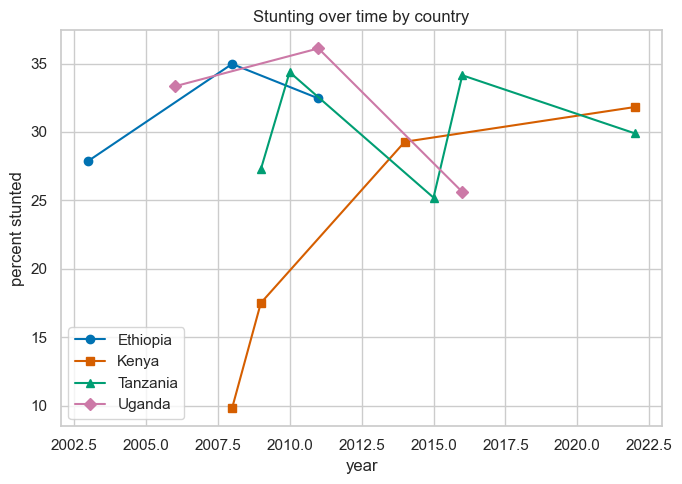

In [182]:
plt.figure(figsize=(7, 5))

# simple color blind friendly colors
country_colors = {
    "Ethiopia": "#0072B2",   # blue
    "Kenya": "#D55E00",      # orange
    "Tanzania": "#009E73",   # green
    "Uganda": "#CC79A7",     # purple
}

# different markers so you can tell them apart even in grey
country_markers = {
    "Ethiopia": "o",
    "Kenya": "s",
    "Tanzania": "^",
    "Uganda": "D",
}

for c in sorted(merged["country"].unique()):
    sub = merged[merged["country"] == c].sort_values("year")
    
    plt.plot(
        sub["year"],
        sub["stunting_percent"],
        marker=country_markers[c],
        color=country_colors[c],
        label=c,
    )

plt.xlabel("year")
plt.ylabel("percent stunted")
plt.title("Stunting over time by country")
plt.legend()
plt.tight_layout()
plt.show()



#### Inequality across all the countries by weallth group. In this section, the plan is to use the most recent DHS survey and compare children HAZ levels acrosss all wealth groups/wealth quantiles. This will help us analyze and see whether there is a gap between the rich and poor.

In [225]:
# find the first and last survey year for each country
survey_years = (
    child_data
    .groupby("country")["survey_year"]
    .agg(["min", "max"])
    .reset_index()
)

survey_years


,country,min,max
0,Ethiopia,2003,2011
1,Kenya,2008,2022
2,Tanzania,2009,2022
3,Uganda,2006,2016


In [232]:
first_last_rows = []

for row in survey_years.itertuples():
    country = row.country
    first_year = row.min
    last_year = row.max
    
    # first survey for this country
    df_first = child_data[
        (child_data["country"] == country)
        & (child_data["survey_year"] == first_year)
    ][["haz", "country", "survey_year"]].copy()
    df_first["timepoint"] = "first survey"
    
    # last / most recent survey
    df_last = child_data[
        (child_data["country"] == country)
        & (child_data["survey_year"] == last_year)
    ][["haz", "country", "survey_year"]].copy()
    df_last["timepoint"] = "last survey"
    
    first_last_rows.append(df_first)
    first_last_rows.append(df_last)

first_last = pd.concat(first_last_rows, ignore_index=True)

first_last.head()


,haz,country,survey_year,timepoint
0,-5.0,Ethiopia,2003,first survey
1,4.0,Ethiopia,2003,first survey
2,0.0,Ethiopia,2003,first survey
3,-5.0,Ethiopia,2003,first survey
4,5.0,Ethiopia,2003,first survey


#### HAZ distribution in the first versus most recent survey.Instead of only looking at averages I also compared the full HAZdistribution for the first and last DHS survey in each country.If the right hand density moves closer to zero that means children are less likely to be severely stunted.


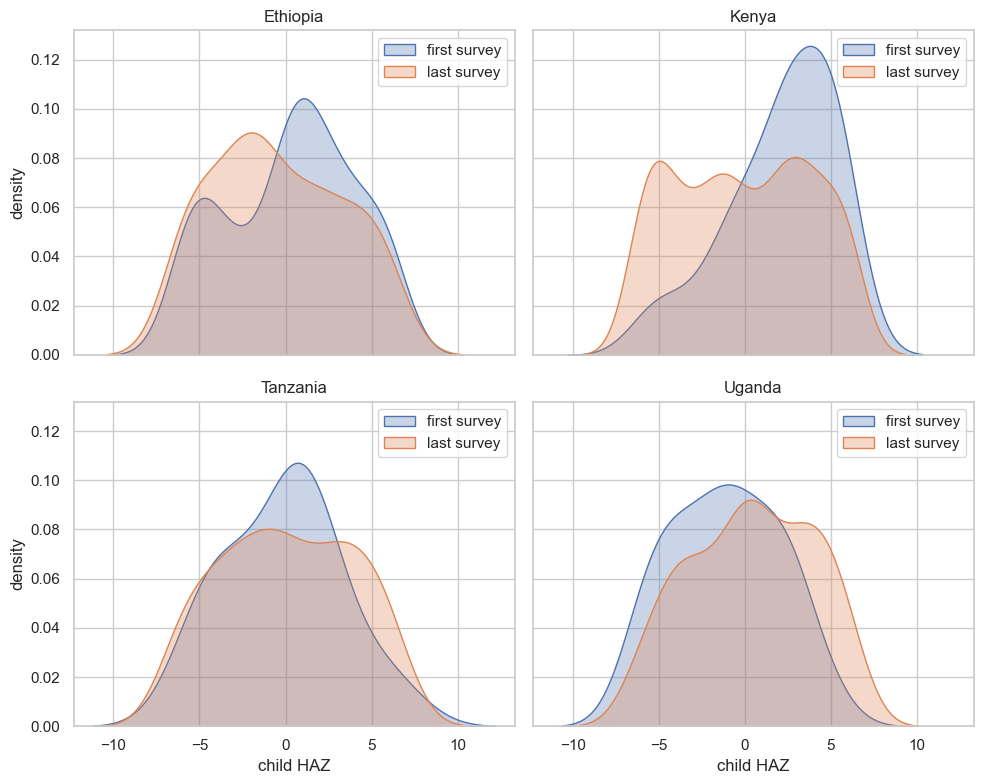

In [235]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

countries = sorted(first_last["country"].unique())

for i, country in enumerate(countries):
    ax = axes[i]
    sub = first_last[first_last["country"] == country]
    
    for t in ["first survey", "last survey"]:
        tmp = sub[sub["timepoint"] == t]
        sns.kdeplot(
            data=tmp,
            x="haz",
            fill=True,
            alpha=0.3,
            ax=ax,
            label=t
        )
    
    ax.set_title(country)
    ax.set_xlabel("child HAZ")
    ax.set_ylabel("density")
    ax.legend()

plt.tight_layout()
plt.show()


### Comparing the first and most recent DHS survey for each country

Here I made a simple before vs after plot to show how stunting changed between
the earliest and the latest DHS survey we have for each country.

Each country has two dots:
* one for the first survey stunting percent
* one for the most recent survey stunting percent

The line between the dots is just to show direction (up or down) without making
a full slope chart. This gives a quick visual summary of long term progress.


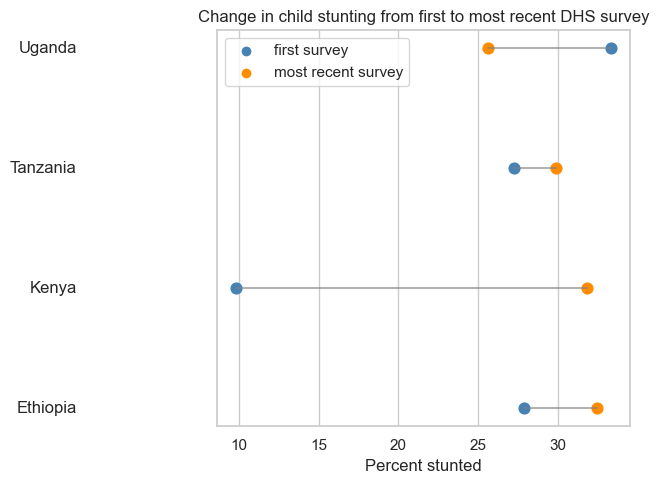

In [238]:
plt.figure(figsize=(7, 5))

# Put countries on y axis for a clean “paired dots” look
y_positions = range(len(change))

for i, row in enumerate(change.itertuples()):
    # two x-values: first survey stunting and last survey stunting
    x_vals = [row.stunting_first, row.stunting_last]
    
    # y position is constant for the pair
    y = [i, i]
    
    # line connecting before/after
    plt.plot(x_vals, y, color="gray", alpha=0.6)
    
    # dots for first and last
    plt.scatter(x_vals[0], y[0], color="steelblue", s=60)
    plt.scatter(x_vals[1], y[1], color="darkorange", s=60)
    
    # label the country on the y-axis
    plt.text(-0.2, i, row.country, va="center", ha="right")

# y-axis as country names
plt.yticks([])  # actual labels are drawn manually above

plt.xlabel("Percent stunted")
plt.title("Change in child stunting from first to most recent DHS survey")

# little legend
plt.scatter([], [], color="steelblue", label="first survey")
plt.scatter([], [], color="darkorange", label="most recent survey")
plt.legend()

plt.tight_layout()
plt.show()
